In [1]:
!pip install langgraph

In [2]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
import os
from typing import TypedDict, List, Literal, Optional
# from dotenv import load_dotenv
# load_dotenv()
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.callbacks import BaseCallbackHandler
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
llm = ChatOpenAI(model="gpt-4o-mini")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## 어제 내용 이어서..(어제 구현 코드 일부)

In [15]:
DOCS = [
    Document(page_content="Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.",
             metadata={"src": "selfrag-intro"}),
    Document(page_content="원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.",
             metadata={"src": "selfrag-paper"}),
    Document(page_content="구현체는 LLM-as-judge 패턴(with_structured_output)으로 reflection token을 대신합니다.",
             metadata={"src": "selfrag-impl"}),
    Document(page_content="관련성 평가에서 yes 문서만 컨텍스트로 추리고, 모두 no면 쿼리 재작성 또는 재검색.",
             metadata={"src": "selfrag-relevance"}),
    Document(page_content="환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.",
             metadata={"src": "selfrag-hallucination"}),
    Document(page_content="유용성 평가는 답변이 질문에 정말 답하는지 1-5점으로 매깁니다. 3점 미만이면 재생성.",
             metadata={"src": "selfrag-usefulness"}),
    Document(page_content="LangGraph는 StateGraph로 노드와 조건부 엣지를 조립해 평가 루프를 자연스럽게 표현합니다.",
             metadata={"src": "langgraph"}),
    Document(page_content="쿼리 재작성은 검색 실패 시 동의어/구체화로 쿼리를 바꿔 다시 검색하는 폴백 패턴입니다.",
             metadata={"src": "query-rewrite"}),
]
vectorstore = FAISS.from_documents(DOCS, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

In [34]:
INIT = {"question": "", "rewritten_question": "",
        "documents": [], "filtered_documents": [], "generation": "",
        "relevance_grades": [], "hallucination_score": "",
        "usefulness_score": 0,
        "relevance_retries": 0, "generation_retries": 0, "max_retries": 4}

In [4]:
class SelfRAGState(TypedDict):
  question : str # 사용자 질문, state가 업데이트되더라도 question은 잘 안바뀜
  rewritten_question: str # 같은 쿼리를 같은 모델에다 던지면 비슷한 답변... 답변이 잘 안나온다면 query를 새로 작성해서 던짐(self-rag의 원래 논문에는 없음 (C-RAG, corrective rag))
  documents : List[Document] # 반환된 문서
  filtered_documents : List[Document] # 관련도 있는 문서 (필터됨)
  generation : str # 생성된 LLM 답변
  relevance_grades : List[str] # 문서별 관련 여부
  hallucination_score : str # 환각 여부
  usefulness_score : int # 1-5점, 유용성
  relevance_retries : int # 문서 검색 했으나 관련도 검사하여 필터링했으나, 개수가 부족하면 다시 검색
  generation_retries : int
  max_tries : int # 무한루프 방지



In [20]:
REL_PROMPT = ChatPromptTemplate.from_messages([
        ('system', '문서가 질문에 대한 답변에 도움이 된다면 "yes", 그렇지 않다면 "no"로만 답변하세요.'),
        ('human', '질문: {question} \n\n문서 내용: {context}')
    ])
RAG_PROMPT = ChatPromptTemplate.from_messages([
    ('system', '다음 문서를 근거로 한국어로 간단히 답하세요. 문서에 없으면 "모름"이라고 답하세요'),
    ('human', '질문 : {question}\n\n문서:\n{context}')
])

REWRITE_PROMPT = ChatPromptTemplate.from_messages([
    ('system', '다음 질문을 의미는 보존하되 검색이 더 잘되도록 동의어, 구체화로 재작성해줘. 한 줄로만'),
    ('human', '원래 질문: {question}')
])

In [21]:
class _Relevance(BaseModel):
  binary : Literal['yes', 'no'] = Field(description = '문서가 질문과 관련이 있는지')

relevance_grader = llm.with_structured_output(_Relevance)

def grade_and_filter_node(state: SelfRAGState) -> dict:
  grades = []
  keep = []

  for d in state['documents']:
    msg = REL_PROMPT.format_messages(question = state['question'], context = d.page_content)
    g = relevance_grader.invoke(msg).binary
    grades.append(g)

    if g == 'yes':
     keep.append(d)

  return {'relevance_grades': grades, 'filtered_documents' : keep}

def generate_filtered_node(state : SelfRAGState) -> dict:
  # 필터링된 문서들을 합쳐서 답변 생성
  ctx = '\n'.join(f" - {d.page_content}" for d in state['filtered_documents'])
  msg = RAG_PROMPT.format_messages(question = state['question'], context = ctx)

  return {'generation' : llm.invoke(msg).content}

def relevance_router(state : SelfRAGState) -> str:
  # 'filtered_document' -> 'filtered_documents'로 수정
  if state['filtered_documents']:
    return 'generate'
  else:
    return 'retrieve'

def retrieve_aware_node(state: SelfRAGState) -> dict:
  q = state['rewritten_question'] or state['question']
  return {'documents' : retriever.invoke(q)}


def rewrite_query_node(state: SelfRAGState) -> dict:
  msg =REWRITE_PROMPT.format_messages(question = state['question'])
  new_q = llm.invoke(msg).content.strip()
  return {'rewritten_question' : new_q}

In [22]:
class _Hallucination(BaseModel):
  binary : Literal['yes', 'no'] = Field(description = '답변이 환각인지 (yes = 문서 밖 정보, no = 근거 있음)')

hallucination_grader = llm.with_structured_output(_Hallucination)

HAL_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "당신은 엄격한 채점관입니다. 답변의 모든 사실이 문서에 명시적으로 기술되어 있어야 합니다. 답변이 주어진 문서에 근거하는지 평가해주세요. 문서 밖 정보면 yes(환각), 근거하면 no"),
    ("human", "문서: \n{context}\n\n답변: {answer}")

])

def grade_hallucination_node(state: SelfRAGState) -> dict:
  docs = state['filtered_documents'] or state['documents']
  ctx = '\n'.join(d.page_content for d in docs)
  msg = HAL_PROMPT.format_messages(context = ctx, answer = state['generation'])
  return {'hallucination_score': hallucination_grader.invoke(msg).binary}

In [23]:
builder = StateGraph(SelfRAGState)

builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_node)
builder.add_node('generate', generate_filtered_node)
builder.add_node('grade_hallucination', grade_hallucination_node)


builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', relevance_router, {'generate':'generate', 'rewrite_query':'rewrite_query'} )
builder.add_edge('rewrite_query', 'retrieve')
builder.add_edge('generate', 'grade_hallucination')
builder.add_edge('grade_hallucination', END)
app = builder.compile()

## 오늘 내용 시작

In [30]:
# retrieve -> grade_relevance -> router -> 연관 문서 있으면 -> generate -> END
#     | <---- rewrite query <-----|

In [31]:
def generate_with_counter(state: SelfRAGState) -> dict:
  docs = state['filtered_documents'] or state['documents']
  ctx = '\n'.join(f"-{d.page_content}" for d in docs)
  msg = RAG_PROMPT.format_messages(question = state['question'], context = ctx)
  return {'generation': llm.invoke(msg).content, 'generation_retries': state['generation_retries'] + 1}

def hallucination_router(state:SelfRAGState) -> str:
  if state['generation_retries'] >= 2:
    return 'end'
  return 'generate' if ['hallucination_score'] == 'yes' else 'end'

In [28]:
builder = StateGraph(SelfRAGState)

builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_node)
builder.add_node('generate', generate_with_counter)
builder.add_node('grade_hallucination', grade_hallucination_node)


builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', relevance_router, {'generate':'generate', 'rewrite_query':'rewrite_query'} )
builder.add_edge('rewrite_query', 'retrieve')
builder.add_edge('generate', 'grade_hallucination')

builder.add_conditional_edges('grade_hallucination', hallucination_router, {'generate':'generate', 'end':END} )

app = builder.compile()

In [35]:
result = app.invoke({**INIT, 'question' : 'self-rag 환각 평가는?'})

In [36]:
result

{'question': 'self-rag 환각 평가는?',
 'rewritten_question': '',
 'documents': [Document(id='59ba5d71-2884-4832-9669-9769185003a4', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='05469414-4a9f-461e-888a-71c6da9abbd7', metadata={'src': 'selfrag-hallucination'}, page_content='환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.'),
  Document(id='8b8f1981-12cb-409c-8ac3-0ac6eec42f0a', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'filtered_documents': [Document(id='59ba5d71-2884-4832-9669-9769185003a4', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='8b8f1981-12cb-409c-8ac3-0ac6eec42f0a', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'generation': 'self-RAG 환각 평가는 LLM이 스스로 판단하는 자가 평가 방식으로, reflection token을 통해 검색 여부와 답변 품질을 표시합니다.',
 're

In [ ]:
# 실습
  # 1. re-generate 하게 할 때, llm의 temperature를 0.7로 초기화 한 새로운 llm으로 생성
  # 2. 재생성 할 때, "이전 답변은 환각이었습니다. 문서에 의존해서 다시 답변하라는 프롬프트,, 를 이용해 재생성"
regen_llm = llm.bind(temperature=0.7)

REGEN_RAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "이전 답변은 환각으로 판정 되었습니다. 사용자의 질문에 대해 문서에 의존해서 다시 답변하세요."),
    ("humna", "문서: \n{context}\n\n답변: {answer}")
])
def generate_with_counter(state: SelfRAGState) -> dict:
  docs = state['filtered_documents'] or state['documents']
  ctx = '\n'.join(f"-{d.page_content}" for d in docs)

  if state['generation_retries'] ==0:
    msg = RAG_PROMPT.format_messages(question = state['question'], context = ctx)
    generation = llm.invoke(msg).content

  else:
    msg = REGEN_RAG_PROMPT.format_messages(question=state['question'],context=ctx,)
    generation = regen_llm.invoke(msg).content

  return {'generation': generation, 'generation_retries': state['generation_retries'] + 1}

In [ ]:
# 강사님 코드
llm_temp = ChatOpenAI(model='gpt-4o-mini', temperature = 0.7)
def generate_1_temp(question, docs):
  ctx = '\n'.join(f"-{d.page_content}" for d in docs)
  return llm_temp.invoke(RAG_PROMPT.format_messages(question=question, context = ctx)).context

HALLUCINATION_PROMPT = ChatPromptTemplate.from_messages([
    ('system', '이전 답변은 환각이었습니다.'),
    ('human', '질문 : {question}\n\n문서: \n{context}')

])

def generate_2_hallucination(question, docs):
  ctx = '\n'.join(f"-{d.page_content}" for d in docs)
  return llm.invoke(HALLUCINATION_PROMPT.format_messages(question=question, context = ctx)).context

### usefulness 기준으로 답변 평가 (IsUse)

In [42]:
class _Usefulness(BaseModel):
  score : int = Field(description='답변의 유용성 1-5점', ge=1, le=5)

usefulness_grader = llm.with_structured_output(_Usefulness)

USE_PROMPT = ChatPromptTemplate.from_messages([
    ('system', '답변이 얼마나 질문에 적합한지, 잘 답변했는지에 대해 1-5점으로 평가. 1=관련 없음, 2=약함, 3=보통, 4=좋음, 5=완벽'),
    ('human', '질문: {question}\n답변: {answer}')
])

def grade_usefulness_node(state: SelfRAGState) -> dict:
  msg = USE_PROMPT.format_messages(question=state['question'], answer = state['generation'])
  return {'usefulness_score': usefulness_grader.invoke(msg).score}

In [ ]:
# retrieve -> grade_relevance -> router ->[연관 문서 O] generate -> grade_hallucination -> router -> 추가[usefulness] -> END
#     | <---- rewrite query <----- |                        | --------------<----------------|

In [40]:

def hallucination_router(state:SelfRAGState) -> str:
  if state['generation_retries'] >= 2:
    return 'usefulness' # 원래는 end였으나, usefulness로 보냄
  return 'generate' if ['hallucination_score'] == 'yes' else 'usefulness' # 그냥 END와 라우터 사이에 'usefulness' 추가

In [44]:
builder = StateGraph(SelfRAGState)

builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_node)
builder.add_node('generate', generate_with_counter)
builder.add_node('grade_hallucination', grade_hallucination_node) # 여기서 이제 usefulness로 가야함
builder.add_node('grade_usefulness', grade_usefulness_node) # usefulness node

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', relevance_router, {'generate':'generate', 'rewrite_query':'rewrite_query'} )
builder.add_edge('rewrite_query', 'retrieve')
builder.add_edge('generate', 'grade_hallucination')

builder.add_conditional_edges('grade_hallucination', hallucination_router, {'generate':'generate', 'usefulness':'grade_usefulness'} )
builder.add_edge('grade_usefulness', END)

app = builder.compile()

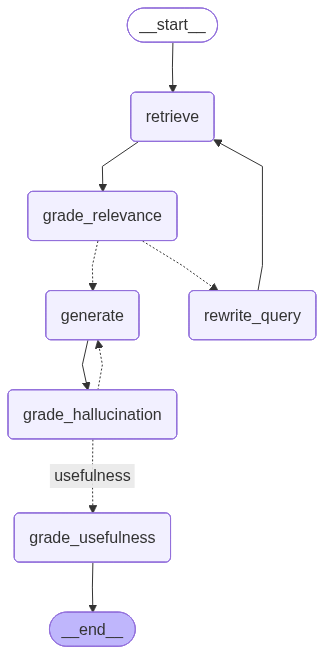

In [45]:
app

In [47]:
result = app.invoke({**INIT, 'question' : 'self-rag 환각 평가는?'})
result

{'question': 'self-rag 환각 평가는?',
 'rewritten_question': '',
 'documents': [Document(id='59ba5d71-2884-4832-9669-9769185003a4', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='05469414-4a9f-461e-888a-71c6da9abbd7', metadata={'src': 'selfrag-hallucination'}, page_content='환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.'),
  Document(id='8b8f1981-12cb-409c-8ac3-0ac6eec42f0a', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'filtered_documents': [Document(id='59ba5d71-2884-4832-9669-9769185003a4', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='05469414-4a9f-461e-888a-71c6da9abbd7', metadata={'src': 'selfrag-hallucination'}, page_content='환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.'),
  Document(id='8b8f1981-12cb-409c-8ac3-0ac6eec42f0a', metadata={'src': 'selfrag-paper'}, page_content='원논문 Sel

답변을 list로 정의해 놓은 다음 측정 (좋은답변, 나쁜답변 등)

In [51]:
Q = "Self-RAG란?"
answers = {
    'good' : 'Self-RAG는 검색, 생성, 평가를 LLM이 스스로 판단하는 자가평가 RAG 입니다.',
    'bad' : '잘 모르겠어요',
    'unrelated' : "오늘 날씨가 좋네요"
}

scores = {}
for label, ans in answers.items():
  msg = USE_PROMPT.format_messages(question=Q, answer=ans)
  scores[label] = usefulness_grader.invoke(msg).score

print(scores)

{'good': 3, 'bad': 1, 'unrelated': 1}


In [52]:
# retrieve -> grade_relevance -> router ->[연관 문서 O] generate -> grade_hallucination -> router -> 추가[usefulness] -> router-> END
#     | <---- rewrite query <----- |                        | --------------<----------------|                             |
#                                                           | ---------------------------------------------< 4점 미만----- |

# 5점 -> END
# 3-4점 -> generate
# 1-2점 -> retrieved

In [61]:
MAX_GENERATION_RETRIES = 5

def usefulness_router(state:SelfRAGState) -> str:
  # 안전장치 추가 필요(무한루프 방지) -> generation_retries, relevance_retries 등
  if state['generation_retries'] >= MAX_GENERATION_RETRIES:
    return 'end'

  score = state['usefulness_score']

  if score == 5:
    return 'end'
  elif score <= 3:
    return 'generate'
  else:
    return 'retrieve'


builder = StateGraph(SelfRAGState)

builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_node)
builder.add_node('generate', generate_with_counter)
builder.add_node('grade_hallucination', grade_hallucination_node)
builder.add_node('grade_usefulness', grade_usefulness_node)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', relevance_router, {'generate':'generate', 'rewrite_query':'rewrite_query'} )
builder.add_edge('rewrite_query', 'retrieve')

builder.add_edge('generate', 'grade_hallucination')
builder.add_conditional_edges('grade_hallucination', hallucination_router, {'generate':'generate', 'usefulness':'grade_usefulness'} )
builder.add_conditional_edges('grade_usefulness',usefulness_router, {'end': END,'generate': 'generate','retrieve': 'retrieve'})

app = builder.compile()

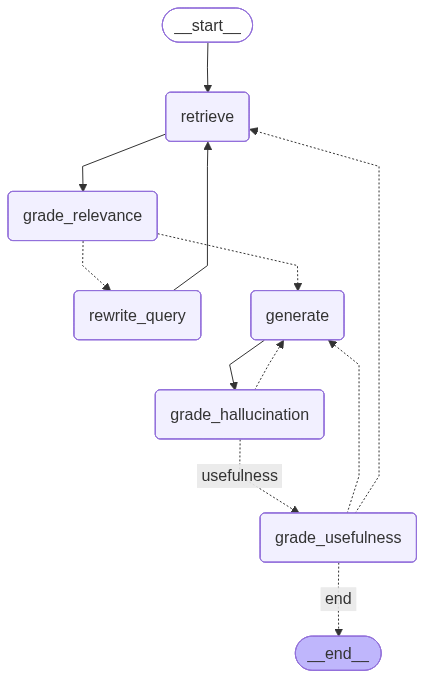

In [62]:
app

In [63]:
result = app.invoke({**INIT, 'question' : 'self-rag 환각 평가는?'})
result

{'question': 'self-rag 환각 평가는?',
 'rewritten_question': '',
 'documents': [Document(id='59ba5d71-2884-4832-9669-9769185003a4', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='05469414-4a9f-461e-888a-71c6da9abbd7', metadata={'src': 'selfrag-hallucination'}, page_content='환각 평가는 답변이 문서에 근거하는지 확인합니다. yes(환각)면 다시 생성합니다.'),
  Document(id='8b8f1981-12cb-409c-8ac3-0ac6eec42f0a', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'filtered_documents': [Document(id='59ba5d71-2884-4832-9669-9769185003a4', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='8b8f1981-12cb-409c-8ac3-0ac6eec42f0a', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'generation': 'Self-RAG 환각 평가는 LLM이 스스로 검색, 생성, 평가를 판단하는 자가 평가 방식으로, reflection token을 통해 검색 여부와 답변 품질을 표

In [79]:
class SelfRAGState(TypedDict):
  question : str # 사용자 질문, state가 업데이트되더라도 question은 잘 안바뀜
  rewritten_question: str # 같은 쿼리를 같은 모델에다 던지면 비슷한 답변... 답변이 잘 안나온다면 query를 새로 작성해서 던짐(self-rag의 원래 논문에는 없음 (C-RAG, corrective rag))
  documents : List[Document] # 반환된 문서
  filtered_documents : List[Document] # 관련도 있는 문서 (필터됨)
  generation : str # 생성된 LLM 답변
  relevance_grades : List[str] # 문서별 관련 여부
  hallucination_score : str # 환각 여부
  usefulness_score : int # 1-5점, 유용성
  relevance_retries : int # 문서 검색 했으나 관련도 검사하여 필터링했으나, 개수가 부족하면 다시 검색
  generation_retries : int
  max_tries : int # 무한루프 방지
  max_retries : int



In [90]:
# 단순히 router에 작성하지 말고, 추가적인 라우터로 활용
def safe_relevance_router(state: SelfRAGState) -> str:
  if state['relevance_retries'] >= state['max_retries']:
    return 'generate'
  if state['filtered_documents']:
    return 'generate'
  return 'rewrite_query'

def safe_hallucination_router(state : SelfRAGState) -> str:
  if state['generation_retries'] >= state['max_retries']:
    return 'usefulness'
  return 'generate' if state['hallucination_score'] == 'yes' else 'usefulness'

def safe_usefulness_router(state : SelfRAGState) -> str:
  score = state['usefulness_score']
  if state['generation_retries'] >= state['max_retries'] or state['relevance_retries'] >= state['max_retries'] :
    return 'end'
  if score >= 5:
    return 'end'
  if score >= 3:
    return 'regenerate'
  return 'reretrieve'


def rewrite_query_counter(state:SelfRAGState) -> dict:
  msg = REWRITE_PROMPT.format_messages(question = state['question'])
  return {'rewritten_question': llm.invoke(msg).content.strip(), 'relevance_retries' : state['relevance_retries']+1}

In [92]:

builder = StateGraph(SelfRAGState)

builder.add_node('retrieve', retrieve_aware_node)
builder.add_node('grade_relevance', grade_and_filter_node)
builder.add_node('rewrite_query', rewrite_query_counter)
builder.add_node('generate', generate_with_counter)
builder.add_node('grade_hallucination', grade_hallucination_node)
builder.add_node('grade_usefulness', grade_usefulness_node)

builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'grade_relevance')
builder.add_conditional_edges('grade_relevance', safe_relevance_router, {'generate':'generate', 'rewrite_query':'rewrite_query'} )
builder.add_edge('rewrite_query', 'retrieve')

builder.add_edge('generate', 'grade_hallucination')
builder.add_conditional_edges('grade_hallucination', safe_hallucination_router, {'generate':'generate', 'usefulness':'grade_usefulness'} )
builder.add_conditional_edges('grade_usefulness',safe_usefulness_router, {'end': END,'regenerate': 'generate','reretrieve': 'retrieve'})

app = builder.compile()

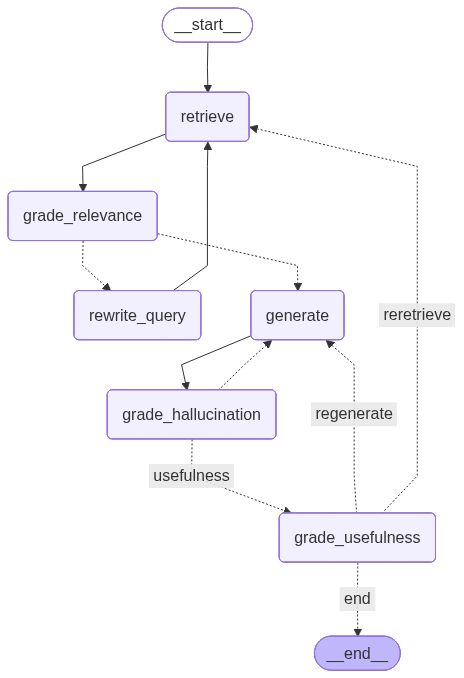

In [93]:
app

In [94]:
result = app.invoke({**INIT, 'question' :'self-rage의 핵심은?', 'max_retries':4})

In [87]:
result

{'question': 'self-rage의 핵심은?',
 'rewritten_question': '',
 'documents': [Document(id='59ba5d71-2884-4832-9669-9769185003a4', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'),
  Document(id='8b8f1981-12cb-409c-8ac3-0ac6eec42f0a', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.'),
  Document(id='df8a0ee2-fe84-4c52-b7a7-abef8b928ce4', metadata={'src': 'selfrag-impl'}, page_content='구현체는 LLM-as-judge 패턴(with_structured_output)으로 reflection token을 대신합니다.')],
 'filtered_documents': [Document(id='8b8f1981-12cb-409c-8ac3-0ac6eec42f0a', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')],
 'generation': 'self-rage의 핵심은 reflection token을 학습시켜 검색 여부와 답변 품질을 표시하는 것입니다.',
 'relevance_grades': ['no', 'yes', 'no'],
 'hallucination_score': 'no',
 'usefulness_score': 2,
 'relevance_retries': 0,
 'generation_retries': 4,
 'max_retries': 4

In [88]:
for chunk in app.stream({**INIT, 'question': 'self-rag의 핵심은?', 'max_retries': 4}):
  for node_name, payload in chunk.items():
    print(node_name, payload) # 청크별 어느 노드에서 어느 답변이 나왔는지 평가 및 디버그 하기 용이함

retrieve {'documents': [Document(id='59ba5d71-2884-4832-9669-9769185003a4', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'), Document(id='8b8f1981-12cb-409c-8ac3-0ac6eec42f0a', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.'), Document(id='df8a0ee2-fe84-4c52-b7a7-abef8b928ce4', metadata={'src': 'selfrag-impl'}, page_content='구현체는 LLM-as-judge 패턴(with_structured_output)으로 reflection token을 대신합니다.')]}
grade_relevance {'relevance_grades': ['yes', 'yes', 'no'], 'filtered_documents': [Document(id='59ba5d71-2884-4832-9669-9769185003a4', metadata={'src': 'selfrag-intro'}, page_content='Self-RAG는 검색·생성·평가를 LLM이 스스로 판단하는 자가 평가 RAG입니다.'), Document(id='8b8f1981-12cb-409c-8ac3-0ac6eec42f0a', metadata={'src': 'selfrag-paper'}, page_content='원논문 Self-RAG는 reflection token을 학습시켜 검색 여부와 답변 품질을 표시합니다.')]}
generate {'generation': 'Self-RAG의 핵심은 LLM이 검색·생성·평가를 스스로 판단하는 자가 평가 RAG이며, reflection to

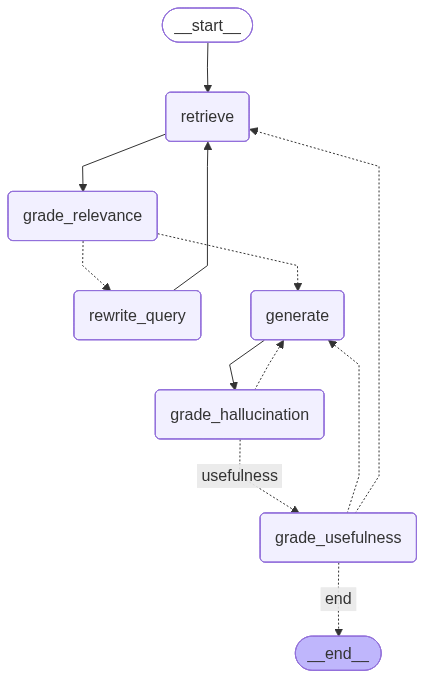

In [89]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

### C-RAG (Corrective RAG)
- 기존 adaptive RAG : query 난이도를 scoring
- self-rag : self evaluate
- CRAG: 중간중간 답변을 수정 -> query rewrite
  - relevance, 기존 yes/no의 binary -> 3가지로 확장, correct (내부지식으로 충분)/ ambiguous(외부검색 필요)/ incorrect

In [95]:
# class _CragGrade(BaseModel):
#   grade : correct / ambiguous / incorrect
#   score : 0.8 (0~1 사이 점수)

In [96]:
# 기존..
# T5의 경우 text encoder -> fine-tuning -> (0.7, 0.2, 0.1) label + logit
  # (0.7, 0.2, 0.1) 0번 값이 가장 크니까 correct이구나

# 이제는 더이상 fine-tuning을 개인이 할 필요/능력이 없음

In [ ]:
class _CragGrade(BaseModel):
#   grade : correct / ambiguous / incorrect
#   score : 0.8 (0~1 사이 점수)

crag_grader = llm.with_structured_output()

CRAG_PROMPT = ChatPromptTemplate.from_messages([
    ('system', '당신은 검색 결과와 질문의 적합도를 평가하는 전문가입니다...'),
    ('human', '질문')
])

def crag_grade_node(state: SelfRAGState)->dict:

In [101]:
class _CragGrade(BaseModel):
  grade: Literal['correct', 'ambiguous', 'incorrect'] = Field(
    description=(
      "검색 결과와 질문의 적합도를 평가 "
      "correct: 내부지식으로 충분, ambiguous: 외부검색 필요, incorrect: 부적합"
    )
  )
  score: float = Field(ge=0.0,le=1.0)

crag_grader = llm.with_structured_output(_CragGrade)

CRAG_PROMPT = ChatPromptTemplate.from_messages([
    ('system', """당신은 검색 결과와 질문의 적합도를 평가하는 전문가입니다.
    검색 결과가 사용자의 질문에 답하기에 충분한지 평가하세요.

    점수 기준:
      - correct: 0.8 이상
      - ambiguous: 0.4 이상 0.8 미만
      - incorrect: 0.4 미만
    """),
    ('human', '질문{question}\n검색 결과:{context} 검색 결과에 대한 적합도를 평가하세요.')
])

def crag_grade_node(state: SelfRAGState) -> dict:
  docs = state['filtered_documents'] or state['documents']
  if not docs:
    return {'crag_grade': "incorrect", "crag_score": 0.0}

  ctx = '\n'.join(f"-{d.page_content}" for d in docs)
  result = crag_grader.invoke(CRAG_PROMPT.format_messages(question=state['question'],context=ctx))

  return {
    'crag_grade': result.grade,
    'crag_score': result.score
  }

In [102]:
result = crag_grade_node({**INIT, 'question': 'Self-rag의 환각 평가 방법?', 'documents': retriever.invoke('Self-rag의 환각 평가 방법?')})

In [103]:
result

{'crag_grade': 'correct', 'crag_score': 0.85}

In [105]:
# filter -> decompose & filter
  # documents -> 문장 단위로 [분해] -> 각 [문장]을 [query]와의 [관련성 평가]

class _StripGrade(BaseModel):
  relevant : bool = Field(description ='이 문장이 질문을 답변하는데 유용한가요?')



strip_grader = llm.with_structured_output(_StripGrade)

STRIP_PROMPT = ChatPromptTemplate.from_messages([
    ('system', "문장 하나가 질문 답변에 유용한지를 yes/no로 평가."),
    ('human', '질문{question}\n문장:{strip}')
])

def knowledge_refine_node(state: SelfRAGState) -> dict:
  refined =[]
  docs = state['filtered_documents'] or state['documents']
  for doc in docs:
    strips = [s.strip() for s in doc.page_content.replace("!", '.').replace('?',".").split(".")]
    kept = []
    for s in strips:
      if len(s) < 10:
        continue
      try:
        r = strip_grader.invoke(STRIP_PROMPT.format_messages(question=state['question'], strip=s))
        if r.relevant:
          kept.append(s)
      except Exception:
        kept.append(s)

    if kept:
      refined.append(
        Document(
          page_content='. '.join(kept),
          metadata=getattr(doc, 'metadata', {})
        )
      )

  return {
    'filtered_documents': refined
  }
